In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('goodreads_fan_books_clean.csv', index_col=0)
print(df.shape)

df.head(10
        )

(1248, 8)


,title,author,pub_year,avg_rate,num_rate,shelved,series_name,series_num
0,Harry Potter and the Philosopher's Stone,J.K. Rowling,1997,4.47,8827238,71462,Harry Potter,1.0
1,Harry Potter and the Chamber of Secrets,J.K. Rowling,1998,4.43,3409926,59741,Harry Potter,2.0
2,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,1999,4.58,3595393,59290,Harry Potter,3.0
3,The Hobbit,J.R.R. Tolkien,1937,4.28,3483329,58644,NaN,NaN
4,Harry Potter and the Goblet of Fire,J.K. Rowling,2000,4.57,3164528,57211,Harry Potter,4.0
5,Harry Potter and the Half-Blood Prince,J.K. Rowling,2005,4.58,2923256,54962,Harry Potter,6.0
6,Harry Potter and the Order of the Phoenix,J.K. Rowling,2003,4.50,3019296,54948,Harry Potter,5.0
7,A Game of Thrones,George R.R. Martin,1996,4.44,2281001,49589,A Song of Ice and Fire,1.0
8,The Fellowship of the Ring,J.R.R. Tolkien,1954,4.38,2617415,45975,The Lord of the Rings,1.0
9,A Clash of Kings,George R.R. Martin,1998,4.41,865168,34640,A Song of Ice and Fire,2.0


In [ ]:
df.isnull().sum()
df.fillna({"series_name": "No Series", "series_num": 0}, inplace=True)




                                      title          author  pub_year  \
0  Harry Potter and the Philosopher's Stone    J.K. Rowling      1997   
1   Harry Potter and the Chamber of Secrets    J.K. Rowling      1998   
2  Harry Potter and the Prisoner of Azkaban    J.K. Rowling      1999   
3                                The Hobbit  J.R.R. Tolkien      1937   
4       Harry Potter and the Goblet of Fire    J.K. Rowling      2000   

   avg_rate  num_rate  shelved   series_name  series_num  
0      4.47   8827238    71462  Harry Potter         1.0  
1      4.43   3409926    59741  Harry Potter         2.0  
2      4.58   3595393    59290  Harry Potter         3.0  
3      4.28   3483329    58644     No Series         0.0  
4      4.57   3164528    57211  Harry Potter         4.0  


AttributeError: 'DataFrame' object has no attribute 'show'

In [5]:
df.isnull().sum()

title          0
author         0
pub_year       0
avg_rate       0
num_rate       0
shelved        0
series_name    0
series_num     0
dtype: int64

In [6]:
df.dtypes


title              str
author             str
pub_year         int64
avg_rate       float64
num_rate         int64
shelved          int64
series_name        str
series_num     float64
dtype: object

In [8]:
df.duplicated(keep=False).sum()

np.int64(4)

In [9]:
df.loc[df.duplicated(keep=False)].sort_values("title")

,title,author,pub_year,avg_rate,num_rate,shelved,series_name,series_num
396,Legendary,Stephanie Garber,2018,4.23,126594,4350,Caraval,2.0
397,Legendary,Stephanie Garber,2018,4.23,126594,4350,Caraval,2.0
455,Under the Whispering Door,T.J. Klune,2021,4.19,103911,3933,No Series,0.0
456,Under the Whispering Door,T.J. Klune,2021,4.19,103911,3933,No Series,0.0


In [10]:
df["author"].value_counts()

author
Terry Pratchett       42
Brandon Sanderson     23
Neil Gaiman           23
Tamora Pierce         23
Jim Butcher           22
                      ..
Josephine Angelini     1
A.K. Larkwood          1
Grace Lin              1
Astrid Scholte         1
Kristen Ashley         1
Name: count, Length: 425, dtype: int64

In [11]:
df.describe()

,pub_year,avg_rate,num_rate,shelved,series_num
count,1248.000000,1248.000000,1.248000e+03,1248.000000,1248.000000
mean,2000.373397,4.095705,2.152800e+05,5023.366987,2.558654
std,86.143974,0.222328,5.484520e+05,6362.742990,4.464046
min,-700.000000,3.430000,5.790000e+03,1572.000000,0.000000
25%,1999.000000,3.950000,3.707375e+04,2054.000000,1.000000
50%,2009.000000,4.100000,7.148850e+04,2991.000000,1.000000
75%,2015.000000,4.250000,1.599362e+05,5127.250000,3.000000
max,2022.000000,4.750000,8.827238e+06,71462.000000,41.000000


<Axes: >

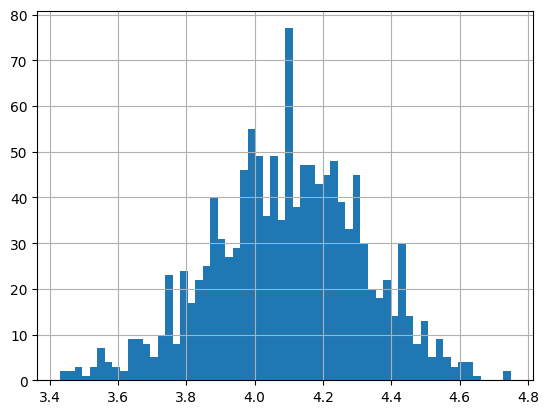

In [14]:
df["avg_rate"].hist(bins=60)

<Axes: xlabel='avg_rate'>

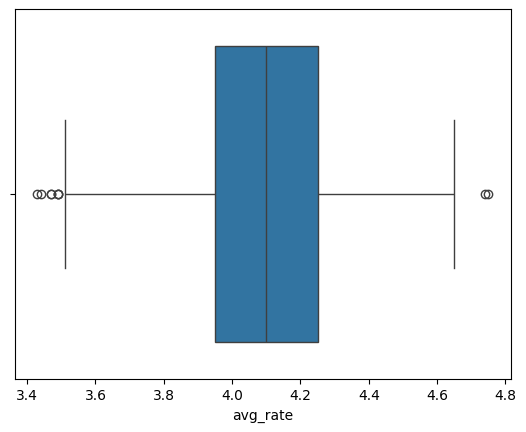

In [15]:
sns.boxplot(x=df["avg_rate"])

In [17]:
df.columns
df_corr = df[[ 'pub_year', 'avg_rate', 'num_rate', 'shelved']].corr()

df_corr
       

,pub_year,avg_rate,num_rate,shelved
pub_year,1.000000,0.069177,-0.074837,-0.001371
avg_rate,0.069177,1.000000,0.117474,0.225953
num_rate,-0.074837,0.117474,1.000000,0.648896
shelved,-0.001371,0.225953,0.648896,1.000000


<Axes: >

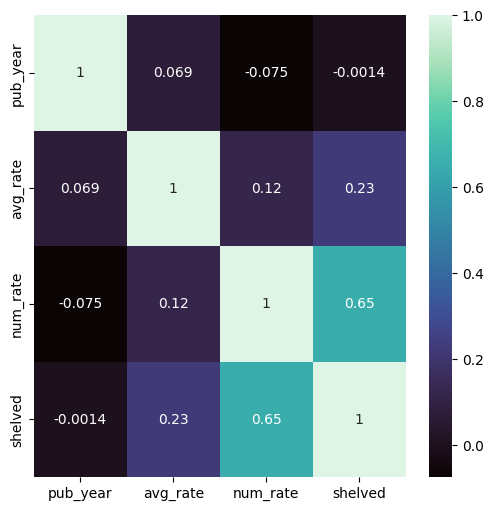

In [19]:
fig, ax = plt.subplots(figsize=(6,6))
sns.heatmap(df_corr, annot=True, cmap="mako")

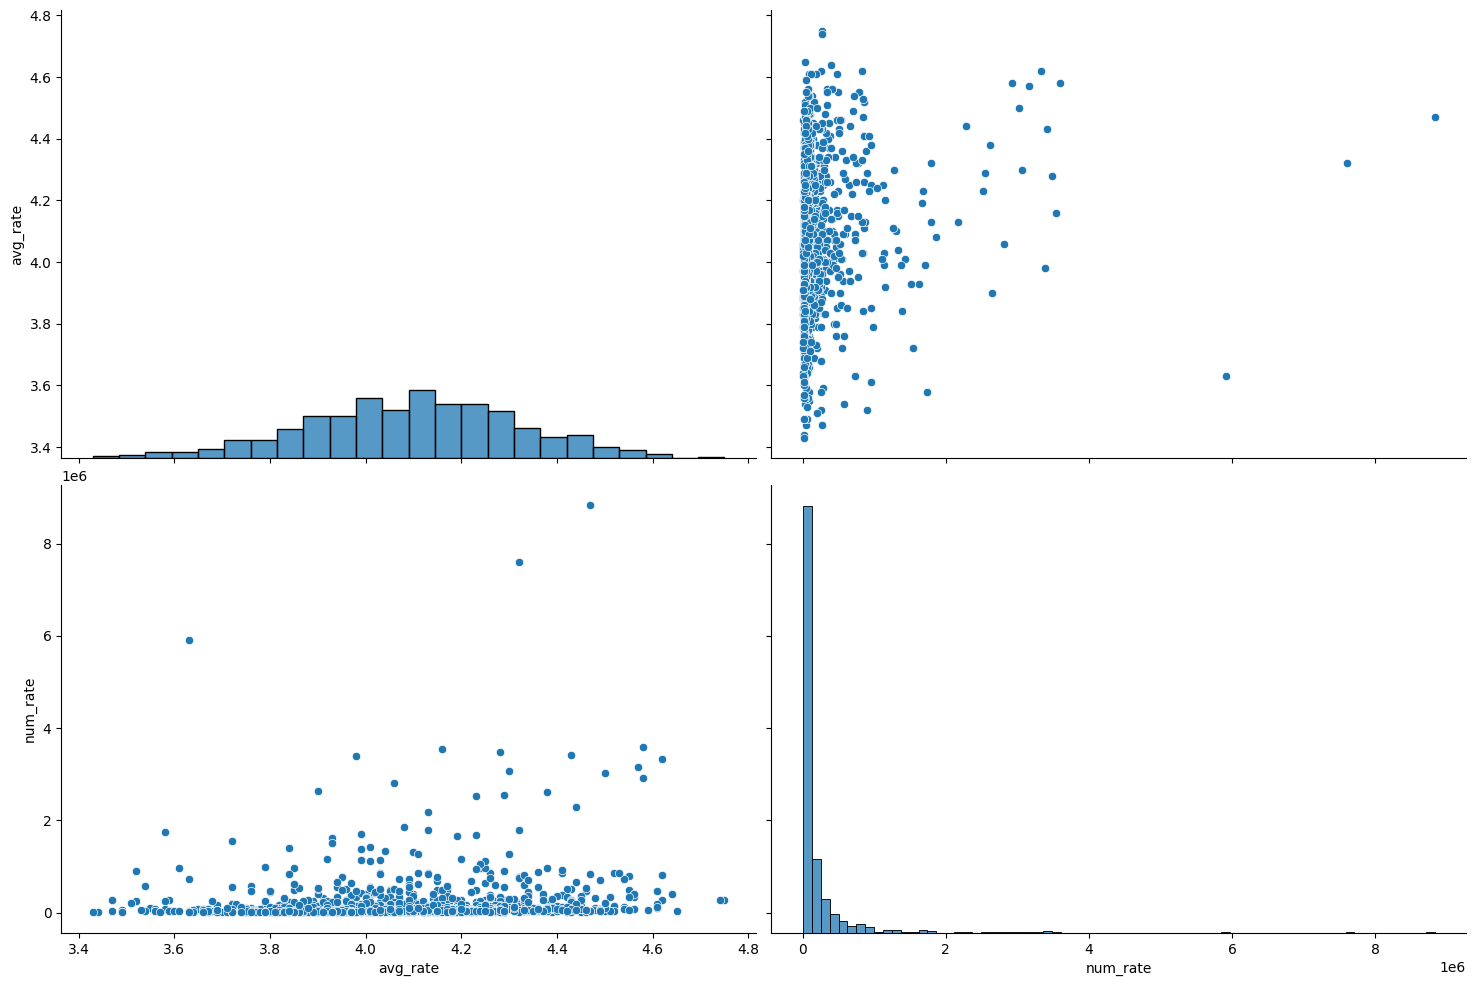

In [20]:
sns.pairplot(df[["avg_rate", "num_rate"]], height=5, aspect=1.5)

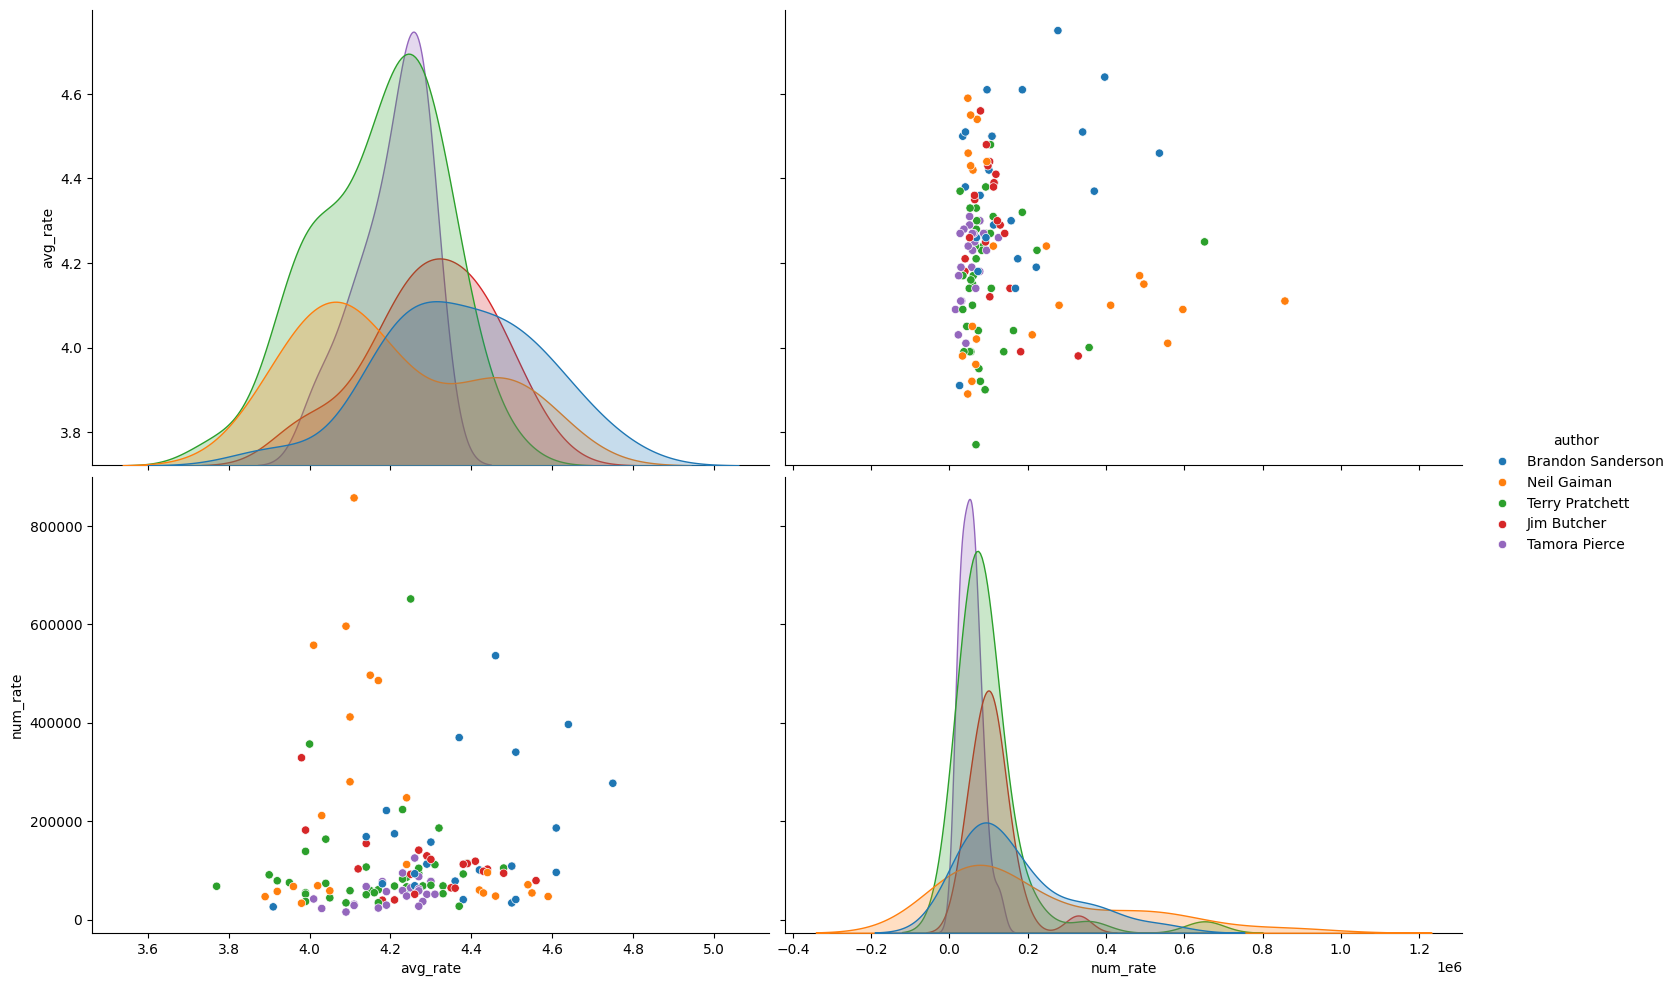

In [23]:
df["author"].value_counts()

df_authors = df[df["author"].isin(["Terry Pratchett", "Brandon Sanderson", "Neil Gaiman", "Tamora Pierce", "Jim Butcher"])]
sns.pairplot(df_authors[["avg_rate", "num_rate", "author"]], height=5, aspect=1.5, diag_kind="kde", hue="author")
